In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [18]:
class SoCalGuesserDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
        self.city_to_idx = {'Los Angeles': 0, 'San Diego': 1, 'SLO': 2, 'Bakersfield': 3, 'Riverside': 4, 'Anaheim': 5}
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        city_name = img_name.split('-')[0]
        city_name = city_name.replace('_', ' ')
        label = self.city_to_idx[city_name]
        return image, label

    

In [19]:
data_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dir = './final_images'
full_dataset = SoCalGuesserDataset(image_dir=train_dir, transform=data_transforms)
total_size = len(full_dataset)
train_size = int(.8 * total_size)
val_size = total_size - train_size
generator = torch.Generator().manual_seed(42)
#train_set, val_set = random_split(full_dataset, [train_size, val_size], generator=generator)
train_loader = DataLoader(
    full_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)
#val_loader = DataLoader(
    #val_set,
    #batch_size=32,
    #shuffle=False,
    #num_workers=0
#)
images, labels = next(iter(train_loader))
print(f"Training images: {len(full_dataset)}")
#print(f"Validation images: {len(val_set)}")
print(f"Batch image shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch labels shape: {labels.shape}") # Should be [32]

Training images: 9181
Batch image shape: torch.Size([32, 3, 112, 112])
Batch labels shape: torch.Size([32])


In [20]:
model = nn.Sequential(
    # --- block 1 ---
    nn.Conv2d(3, 48, kernel_size=7),
    nn.BatchNorm2d(48),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # --- block 2 ---
    nn.Conv2d(48, 96, kernel_size=5),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # --- block 3 ---
    nn.Conv2d(96, 96, kernel_size=3),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # --- classifier ---
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(96, 96),
    nn.ReLU(),
    nn.Linear(96, 6),
)

In [21]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
loss_history = []
#val_acc_history = []
train_acc_history = []
epochs = 85
for epoch in range(epochs):
    # --- training ---
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        total_loss += loss.item() * len(y_batch)
        predicted_classes = torch.argmax(pred, dim=1)
        correct += (predicted_classes == y_batch).sum().item()
        n += len(y_batch)

    train_acc_history.append(correct / n)
    # --- evaluation ---
    #model.eval()
    #val_loss, val_correct, val_n = 0.0, 0, 0
    #with torch.no_grad():
        #for X_val, y_val in val_loader:
            #X_val, y_val = X_val.to(device), y_val.to(device)
            #val_pred = model(X_val)
            #v_loss = loss_fn(val_pred, y_val)
            #val_loss += v_loss.item() * len(y_val)
            #val_predicted_classes = torch.argmax(val_pred, dim=1)
            #val_correct += (val_predicted_classes == y_val).sum().item()
            #val_n += len(y_val)
    #val_acc = val_correct / val_n
    #val_acc_history.append(val_acc)
    print(f"Epoch {epoch+1:2d}/{epochs}  "
          f"loss={total_loss/n:.4f}  "
          f"train_acc={correct/n:.3f}  "
          #f"val_acc={val_acc:.3f}"
    )

Epoch  1/85  loss=1.1274  train_acc=0.590  
Epoch  2/85  loss=0.8726  train_acc=0.686  
Epoch  3/85  loss=0.7920  train_acc=0.719  
Epoch  4/85  loss=0.7233  train_acc=0.746  
Epoch  5/85  loss=0.6737  train_acc=0.762  
Epoch  6/85  loss=0.6582  train_acc=0.762  
Epoch  7/85  loss=0.6311  train_acc=0.776  
Epoch  8/85  loss=0.6129  train_acc=0.788  
Epoch  9/85  loss=0.5747  train_acc=0.799  
Epoch 10/85  loss=0.5523  train_acc=0.808  
Epoch 11/85  loss=0.5428  train_acc=0.804  
Epoch 12/85  loss=0.5284  train_acc=0.811  
Epoch 13/85  loss=0.5113  train_acc=0.818  
Epoch 14/85  loss=0.4932  train_acc=0.824  
Epoch 15/85  loss=0.4791  train_acc=0.830  
Epoch 16/85  loss=0.4575  train_acc=0.839  
Epoch 17/85  loss=0.4598  train_acc=0.838  
Epoch 18/85  loss=0.4399  train_acc=0.845  
Epoch 19/85  loss=0.4370  train_acc=0.843  
Epoch 20/85  loss=0.4093  train_acc=0.854  
Epoch 21/85  loss=0.3993  train_acc=0.858  
Epoch 22/85  loss=0.3973  train_acc=0.860  
Epoch 23/85  loss=0.3914  train_

In [24]:
torch.save(model.state_dict(), 'final_full_cnn_85.pt')

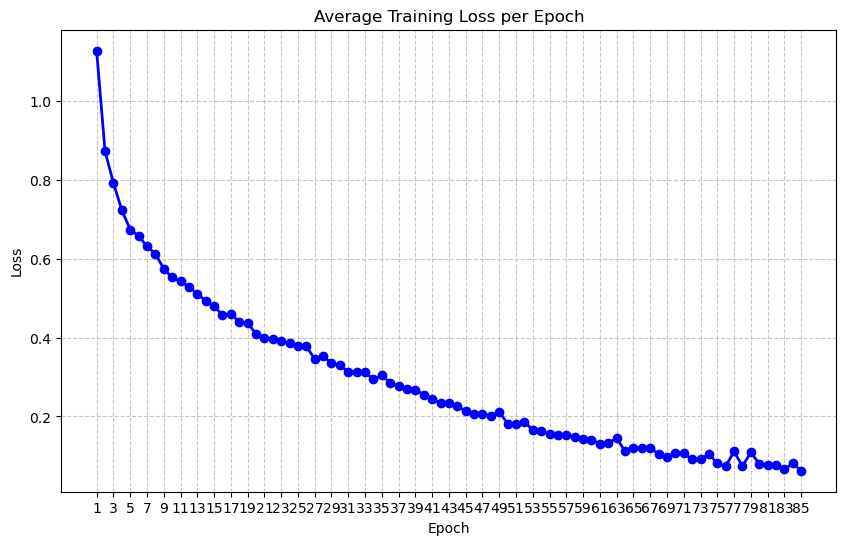

In [23]:
import matplotlib.pyplot as plt

# You ran 30 epochs
epochs = 85

# Figure out exactly how many batches make up one epoch
batches_per_epoch = len(loss_history) // epochs

epoch_losses = []

# Loop through and calculate the average loss for each epoch
for i in range(epochs):
    # Grab the specific chunk of batches for this epoch
    start_idx = i * batches_per_epoch
    end_idx = start_idx + batches_per_epoch
    epoch_chunk = loss_history[start_idx:end_idx]
    
    # Calculate the average and save it
    epoch_avg = sum(epoch_chunk) / len(epoch_chunk)
    epoch_losses.append(epoch_avg)

# Plot the newly averaged data
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', color='blue', linewidth=2)

plt.title('Average Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

# Force the x-axis to display clean, whole numbers from 1 to 30
plt.xticks(range(1, epochs + 1, 2)) 

plt.show()